[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QuantLet/EMQA/blob/main/EMQA_delta_hedging/EMQA_delta_hedging.ipynb)

# EMQA_delta_hedging
Delta hedging demonstration for energy options: dynamically adjusting the hedge ratio to maintain a delta-neutral portfolio. Shows how delta changes with spot price and time to expiration.
**Output:** `deriv_delta_hedging.pdf`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'none',
    'axes.facecolor': 'none',
    'savefig.facecolor': 'none',
    'savefig.transparent': True,
    'axes.grid': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'figure.figsize': (12, 6),
})

COLORS = {
    'blue': '#1A3A6E', 'red': '#CD0000', 'green': '#2E7D32',
    'orange': '#E67E22', 'purple': '#8E44AD', 'gray': '#808080',
    'cyan': '#00BCD4', 'amber': '#B5853F'
}

def save_fig(fig, name):
    fig.savefig(name, bbox_inches='tight', transparent=True, dpi=300,
                facecolor='none', edgecolor='none')
    print(f"Saved: {name}")
    if name.endswith('.pdf'):
        png_name = name[:-4] + '.png'
        fig.savefig(png_name, bbox_inches='tight', transparent=True, dpi=300,
                    facecolor='none', edgecolor='none')
        print(f"Saved: {png_name}")

In [2]:
# Black-Scholes formulas for pricing and Greeks

def bs_d1(S, K, T, r, sigma):
    """Calculate d1 parameter for Black-Scholes"""
    return (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

def bs_d2(S, K, T, r, sigma):
    """Calculate d2 parameter for Black-Scholes"""
    return bs_d1(S, K, T, r, sigma) - sigma * np.sqrt(T)

def bs_call_price(S, K, T, r, sigma):
    """Black-Scholes call option price"""
    if T <= 0:
        return np.maximum(S - K, 0)
    d1 = bs_d1(S, K, T, r, sigma)
    d2 = bs_d2(S, K, T, r, sigma)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def bs_delta_call(S, K, T, r, sigma):
    """Delta of a call option (dC/dS)"""
    if T <= 0:
        return np.where(S > K, 1.0, 0.0)
    d1 = bs_d1(S, K, T, r, sigma)
    return norm.cdf(d1)

def bs_gamma(S, K, T, r, sigma):
    """Gamma of an option (d2C/dS2)"""
    if T <= 0:
        return 0.0
    d1 = bs_d1(S, K, T, r, sigma)
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

# Vectorized versions
bs_call_price_v = np.vectorize(bs_call_price)
bs_delta_call_v = np.vectorize(bs_delta_call)
bs_gamma_v = np.vectorize(bs_gamma)

In [3]:
# Option parameters (energy option, EUR/MWh)
K = 100  # Strike price (EUR/MWh)
r = 0.04  # Risk-free rate
sigma = 0.35  # Volatility (35%)

# Generate spot price range
S_range = np.linspace(60, 140, 300)

# Calculate delta for different times to expiration
T_values = [1.0, 0.5, 0.25, 0.1, 0.01]  # Years to expiration
T_labels = ['1 Year', '6 Months', '3 Months', '1 Month', '1 Week']

delta_curves = {}
for T, label in zip(T_values, T_labels):
    delta_curves[label] = bs_delta_call_v(S_range, K, T, r, sigma)

print(f"Strike price: €{K}/MWh")
print(f"Volatility: {sigma*100:.0f}%")
print(f"Risk-free rate: {r*100:.1f}%")

Strike price: €100/MWh
Volatility: 35%
Risk-free rate: 4.0%


In [4]:
# Simulate delta hedging over time
np.random.seed(42)

# Simulation parameters
S0 = 100  # Initial spot price (ATM)
T_total = 0.25  # 3 months to expiration
n_steps = 63  # Daily rebalancing (~63 trading days in 3 months)
dt = T_total / n_steps

# Simulate GBM price path
Z = np.random.standard_normal(n_steps)
S_path = np.zeros(n_steps + 1)
S_path[0] = S0

for i in range(n_steps):
    S_path[i+1] = S_path[i] * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z[i])

# Calculate delta at each step
T_remaining = np.linspace(T_total, 0, n_steps + 1)
delta_path = np.array([bs_delta_call(S_path[i], K, max(T_remaining[i], 0.001), r, sigma) 
                       for i in range(n_steps + 1)])

# Time array
time_days = np.arange(n_steps + 1)

print(f"Initial price: €{S0:.2f}/MWh")
print(f"Final price: €{S_path[-1]:.2f}/MWh")
print(f"Initial delta: {delta_path[0]:.4f}")
print(f"Final delta: {delta_path[-1]:.4f}")

Initial price: €100.00/MWh
Final price: €77.96/MWh
Initial delta: 0.5575
Final delta: 0.0000


Saved: deriv_delta_hedging.pdf


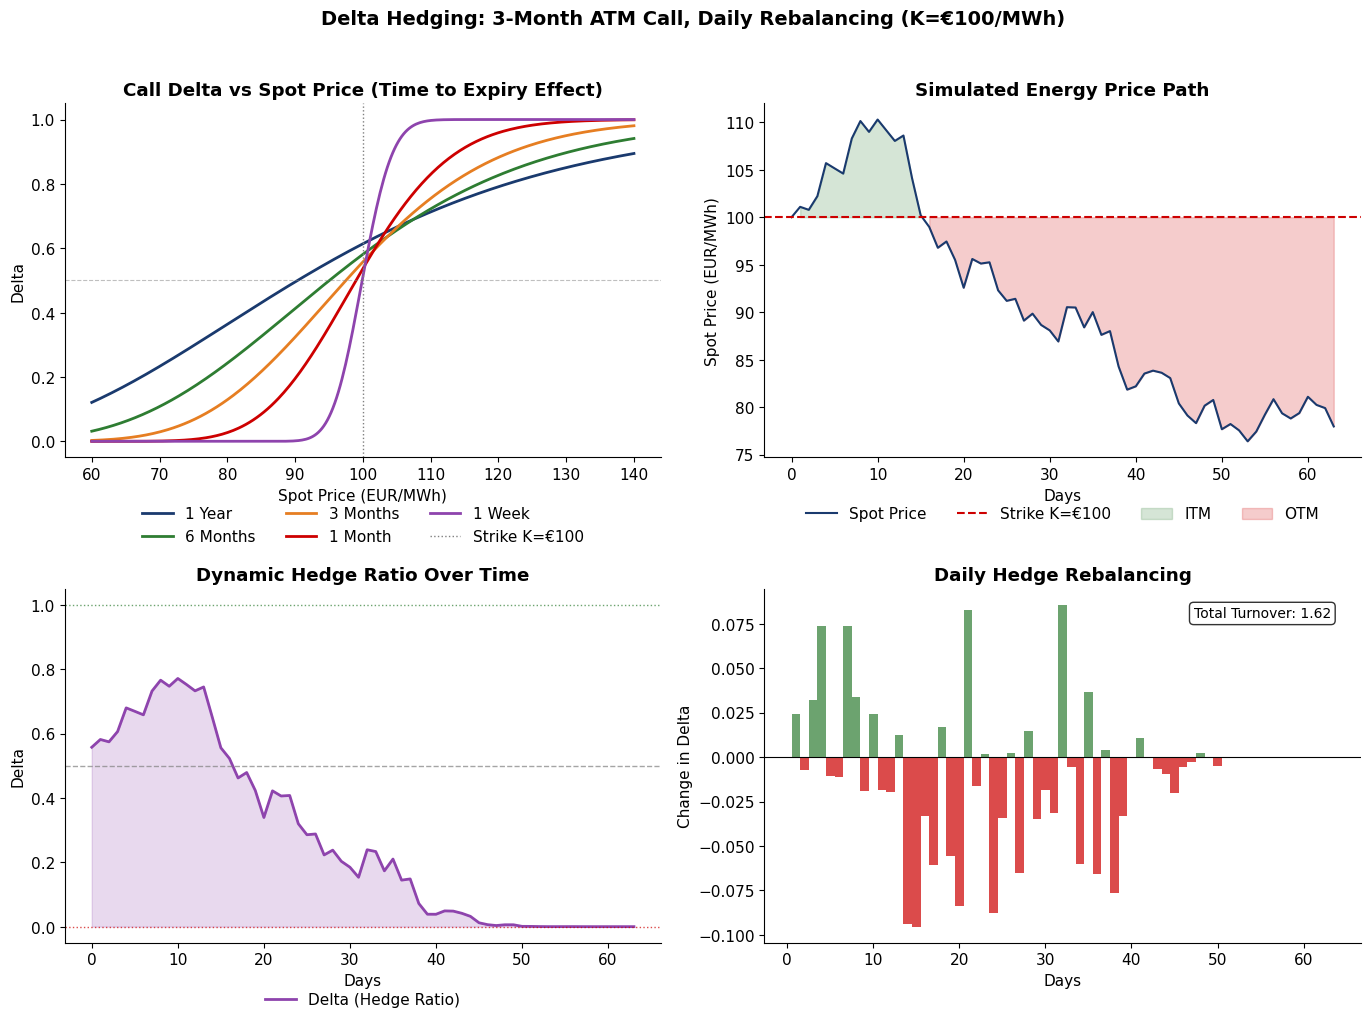

In [5]:
# Create 2x2 panel figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Delta vs Spot Price for different T
ax1 = axes[0, 0]
colors_ttm = [COLORS['blue'], COLORS['green'], COLORS['orange'], COLORS['red'], COLORS['purple']]
for i, (label, delta) in enumerate(delta_curves.items()):
    ax1.plot(S_range, delta, color=colors_ttm[i], linewidth=2, label=label)
ax1.axvline(K, color=COLORS['gray'], linestyle=':', linewidth=1, label=f'Strike K=€{K}')
ax1.axhline(0.5, color=COLORS['gray'], linestyle='--', linewidth=0.8, alpha=0.5)
ax1.set_xlabel('Spot Price (EUR/MWh)')
ax1.set_ylabel('Delta')
ax1.set_title('Call Delta vs Spot Price (Time to Expiry Effect)', fontweight='bold')
ax1.set_ylim(-0.05, 1.05)
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), frameon=False, ncol=3)

# Panel 2: Simulated Price Path
ax2 = axes[0, 1]
ax2.plot(time_days, S_path, color=COLORS['blue'], linewidth=1.5, label='Spot Price')
ax2.axhline(K, color=COLORS['red'], linestyle='--', linewidth=1.5, label=f'Strike K=€{K}')
ax2.fill_between(time_days, S_path, K, where=(S_path > K), 
                 color=COLORS['green'], alpha=0.2, label='ITM')
ax2.fill_between(time_days, S_path, K, where=(S_path < K),
                 color=COLORS['red'], alpha=0.2, label='OTM')
ax2.set_xlabel('Days')
ax2.set_ylabel('Spot Price (EUR/MWh)')
ax2.set_title('Simulated Energy Price Path', fontweight='bold')
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), frameon=False, ncol=4)

# Panel 3: Delta Path (Hedge Ratio Over Time)
ax3 = axes[1, 0]
ax3.plot(time_days, delta_path, color=COLORS['purple'], linewidth=2, label='Delta (Hedge Ratio)')
ax3.fill_between(time_days, 0, delta_path, alpha=0.2, color=COLORS['purple'])
ax3.axhline(0.5, color=COLORS['gray'], linestyle='--', linewidth=1, alpha=0.7)
ax3.axhline(1.0, color=COLORS['green'], linestyle=':', linewidth=1, alpha=0.7)
ax3.axhline(0.0, color=COLORS['red'], linestyle=':', linewidth=1, alpha=0.7)
ax3.set_xlabel('Days')
ax3.set_ylabel('Delta')
ax3.set_title('Dynamic Hedge Ratio Over Time', fontweight='bold')
ax3.set_ylim(-0.05, 1.05)
ax3.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), frameon=False)

# Panel 4: Hedge Rebalancing (Change in Delta)
ax4 = axes[1, 1]
delta_change = np.diff(delta_path)
colors_bar = [COLORS['green'] if x >= 0 else COLORS['red'] for x in delta_change]
ax4.bar(time_days[1:], delta_change, color=colors_bar, alpha=0.7, width=1)
ax4.axhline(0, color='black', linewidth=0.8)
ax4.set_xlabel('Days')
ax4.set_ylabel('Change in Delta')
ax4.set_title('Daily Hedge Rebalancing', fontweight='bold')

# Add annotation
total_trades = np.sum(np.abs(delta_change))
ax4.text(0.95, 0.95, f'Total Turnover: {total_trades:.2f}', 
         transform=ax4.transAxes, fontsize=10, verticalalignment='top',
         horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

fig.suptitle('Delta Hedging: 3-Month ATM Call, Daily Rebalancing (K=€100/MWh)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, 'deriv_delta_hedging.pdf')
plt.show()

In [6]:
# Calculate hedging P&L
# Short 1 call option, dynamically hedge with delta units of underlying

# Initial option value
C0 = bs_call_price(S0, K, T_total, r, sigma)

# Calculate P&L from delta hedging
cash = C0  # Premium received from selling call
shares_held = delta_path[0]  # Initial hedge
cash -= shares_held * S_path[0]  # Cost of initial hedge

# Daily rebalancing
rebalancing_costs = []
for i in range(1, n_steps + 1):
    # Rebalance to new delta
    shares_change = delta_path[i] - shares_held
    cost = shares_change * S_path[i]
    cash -= cost
    rebalancing_costs.append(cost)
    shares_held = delta_path[i]

# Final settlement
final_payoff = max(S_path[-1] - K, 0)  # Call payoff (we are short)
final_stock_value = shares_held * S_path[-1]
final_pnl = cash + final_stock_value - final_payoff

print("=" * 50)
print("DELTA HEDGING P&L SUMMARY")
print("=" * 50)
print(f"Initial option premium received: €{C0:.4f}")
print(f"Final option payoff (liability): €{final_payoff:.4f}")
print(f"Final hedge P&L: €{final_pnl:.4f}")
print(f"Number of rebalancing trades: {n_steps}")
print(f"\nNote: Perfect delta hedging in continuous time")
print(f"would yield exactly zero P&L (self-financing).")

DELTA HEDGING P&L SUMMARY
Initial option premium received: €7.4467
Final option payoff (liability): €0.0000
Final hedge P&L: €0.4195
Number of rebalancing trades: 63

Note: Perfect delta hedging in continuous time
would yield exactly zero P&L (self-financing).
